# Notebook 03 : CNN from scratch vs transfer learning

## Courte revue de l'état de l'art

Deux familles d'approches dominent aujourd'hui la classification d'images en deep learning. Entraîner un **réseau de neurones convolutif from scratch** permet à l'architecture et aux filtres de s'adapter exactement au domaine cible, au prix d'avoir besoin d'assez de données annotées et de calcul pour apprendre des filtres bas niveau utiles à partir de rien. Le **transfer learning** part d'un réseau pré-entraîné sur un grand dataset d'images génériques, typiquement ImageNet. Il réutilise ses filtres précoces (contours, textures, dégradés de couleur) et ne réentraîne que la ou les couches de classification finale. C'est l'approche standard quand les données annotées ou le calcul sont limités.

Une réserve toutefois : ces filtres ont été appris sur des photographies naturelles, pas sur de la microscopie colorée. Le bénéfice sur un domaine aussi éloigné d'ImageNet n'est pas garanti, il mérite d'être mesuré plutôt que supposé.

Ce notebook entraîne un modèle de chaque famille sur les mêmes données et les compare directement, plutôt que d'en choisir un a priori.

## 1. Configuration

In [1]:
import ssl
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from IPython.display import Markdown, display
from PIL import Image
from sklearn.metrics import accuracy_score, f1_score
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms

# Le magasin de certificats Windows de cette machine contient une entrée qui fait
# lever ASN1_NOT_ENOUGH_DATA a ssl.create_default_context(), ce qui casserait
# sinon le telechargement des poids pre-entraines de resnet18 plus bas. On redirige
# le chargement par defaut des certificats vers le bundle CA de certifi (fix local au process).
try:
    import certifi

    _certifi_bundle = certifi.where()
    _original_load_default_certs = ssl.SSLContext.load_default_certs

    def _patched_load_default_certs(self, purpose=ssl.Purpose.SERVER_AUTH):
        try:
            self.load_verify_locations(cafile=_certifi_bundle)
        except Exception:
            _original_load_default_certs(self, purpose)

    ssl.SSLContext.load_default_certs = _patched_load_default_certs
except Exception:
    pass

sns.set_theme(style="whitegrid")
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cpu")  # pas de CUDA sur cette machine
PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

IMG_SIZE = 64
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]
LABEL_TO_IDX = {"Uninfected": 0, "Parasitized": 1}
IDX_TO_LABEL = {v: k for k, v in LABEL_TO_IDX.items()}

print(f"Device : {DEVICE}")

Device : cpu


## 2. Chargement des manifestes et sous-échantillonnage du train

**Note de budget CPU :** cette machine n'a pas de GPU CUDA. Les benchmarks de la section 3 montrent qu'une epoch sur les ~19 300 images d'entraînement prend largement moins d'une minute par modèle, à une résolution de 64x64.

Le jeu d'entraînement est malgré tout sous-échantillonné, pour garder de la marge et éviter des exécutions longues : un **échantillon stratifié de 3 000 Parasitized et 3 000 Uninfected, soit 6 000 images**, tiré avec une seed fixe. La validation utilise le split de validation complet, l'évaluation n'étant qu'une passe avant, donc peu coûteuse.

In [2]:
train_full = pd.read_csv(PROCESSED_DIR / "train.csv")
val_df = pd.read_csv(PROCESSED_DIR / "val.csv")

N_PER_CLASS = 3000
train_df = (
    train_full.groupby("label", group_keys=False)
    .sample(n=N_PER_CLASS, random_state=SEED)
    .reset_index(drop=True)
)

print(f"Jeu d'entraînement complet : {len(train_full):,} images")
print(f"Jeu d'entraînement sous-échantillonné utilisé : {len(train_df):,} images")
display(train_df["label"].value_counts())
print(f"Jeu de validation (complet, sans sous-échantillonnage) : {len(val_df):,} images")
display(val_df["label"].value_counts())

Jeu d'entraînement complet : 19,915 images
Jeu d'entraînement sous-échantillonné utilisé : 6,000 images


label
Parasitized    3000
Uninfected     3000
Name: count, dtype: int64

Jeu de validation (complet, sans sous-échantillonnage) : 3,623 images


label
Uninfected     2050
Parasitized    1573
Name: count, dtype: int64

## 3. Datasets, transformations et dataloaders

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class MalariaCellDataset(Dataset):
    '''Même définition que dans le Notebook 02, reprise ici pour garder ce notebook autonome.'''

    def __init__(self, manifest_df: pd.DataFrame, root_dir: Path, transform=None):
        self.df = manifest_df.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.root_dir / row["path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, LABEL_TO_IDX[row["label"]]


train_dataset = MalariaCellDataset(train_df, PROJECT_ROOT, transform=train_transform)
val_dataset = MalariaCellDataset(val_df, PROJECT_ROOT, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=0)

print(f"{len(train_loader)} batchs d'entraînement, {len(val_loader)} batchs de validation par epoch")

188 batchs d'entraînement, 57 batchs de validation par epoch


## 4. Modèle 1 : petit CNN from scratch

In [4]:
class SimpleCNN(nn.Module):
    '''3 blocs convolutifs + petite tête de classification, entraîné à partir de poids initialisés aléatoirement.'''

    def __init__(self, num_classes: int = 2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 64 -> 32
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32 -> 16
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 16 -> 8
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


simple_cnn = SimpleCNN().to(DEVICE)
n_params = sum(p.numel() for p in simple_cnn.parameters())
n_trainable = sum(p.numel() for p in simple_cnn.parameters() if p.requires_grad)
print(f"SimpleCNN : {n_params:,} paramètres au total, {n_trainable:,} entraînables")

SimpleCNN : 548,258 paramètres au total, 548,258 entraînables


## 5. Modèle 2 : transfer learning avec resnet18

In [5]:
def build_resnet18_transfer(num_classes: int = 2) -> nn.Module:
    '''resnet18 pré-entraîné sur ImageNet, backbone gelé, seule la couche fc finale est réentraînée.'''
    net = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    for param in net.parameters():
        param.requires_grad = False
    net.fc = nn.Linear(net.fc.in_features, num_classes)  # fc est entraînable par défaut (couche neuve)
    return net


resnet_transfer = build_resnet18_transfer().to(DEVICE)
n_params = sum(p.numel() for p in resnet_transfer.parameters())
n_trainable = sum(p.numel() for p in resnet_transfer.parameters() if p.requires_grad)
print(f"resnet18 transfer : {n_params:,} paramètres au total, {n_trainable:,} entraînables (couche fc uniquement)")

resnet18 transfer : 11,177,538 paramètres au total, 1,026 entraînables (couche fc uniquement)


## 6. Boucle d'entraînement

In [6]:
def evaluate(model, loader):
    model.eval()
    total_loss, all_preds, all_labels = 0.0, [], []
    criterion = nn.CrossEntropyLoss()
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            all_preds.extend(out.argmax(dim=1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, pos_label=LABEL_TO_IDX["Parasitized"])
    return avg_loss, acc, f1


def train_model(model, train_loader, val_loader, epochs, lr, name):
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_f1": []}

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, all_preds, all_labels = 0.0, [], []
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            all_preds.extend(out.argmax(dim=1).detach().cpu().numpy())
            all_labels.extend(y.cpu().numpy())

        train_loss = running_loss / len(train_loader.dataset)
        train_acc = accuracy_score(all_labels, all_preds)
        val_loss, val_acc, val_f1 = evaluate(model, val_loader)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_f1"].append(val_f1)

        print(
            f"[{name}] epoch {epoch}/{epochs} - "
            f"train_loss {train_loss:.4f} train_acc {train_acc:.4f} | "
            f"val_loss {val_loss:.4f} val_acc {val_acc:.4f} val_f1 {val_f1:.4f}"
        )

    elapsed = time.time() - t0
    print(f"[{name}] temps d'entraînement total : {elapsed:.1f}s pour {epochs} epochs")
    return history, elapsed


EPOCHS = 8
LR = 1e-3

In [7]:
history_cnn, time_cnn = train_model(simple_cnn, train_loader, val_loader, EPOCHS, LR, "SimpleCNN")

[SimpleCNN] epoch 1/8 - train_loss 0.4374 train_acc 0.7868 | val_loss 0.1668 val_acc 0.9473 val_f1 0.9384


[SimpleCNN] epoch 2/8 - train_loss 0.1897 train_acc 0.9370 | val_loss 0.1272 val_acc 0.9586 val_f1 0.9509


[SimpleCNN] epoch 3/8 - train_loss 0.1652 train_acc 0.9478 | val_loss 0.1114 val_acc 0.9625 val_f1 0.9562


[SimpleCNN] epoch 4/8 - train_loss 0.1545 train_acc 0.9505 | val_loss 0.1073 val_acc 0.9658 val_f1 0.9602


[SimpleCNN] epoch 5/8 - train_loss 0.1495 train_acc 0.9510 | val_loss 0.1115 val_acc 0.9649 val_f1 0.9589


[SimpleCNN] epoch 6/8 - train_loss 0.1475 train_acc 0.9550 | val_loss 0.1058 val_acc 0.9652 val_f1 0.9594


[SimpleCNN] epoch 7/8 - train_loss 0.1445 train_acc 0.9515 | val_loss 0.1066 val_acc 0.9658 val_f1 0.9600


[SimpleCNN] epoch 8/8 - train_loss 0.1421 train_acc 0.9540 | val_loss 0.1010 val_acc 0.9672 val_f1 0.9618
[SimpleCNN] temps d'entraînement total : 119.9s pour 8 epochs


In [8]:
history_resnet, time_resnet = train_model(resnet_transfer, train_loader, val_loader, EPOCHS, LR, "resnet18-transfer")

[resnet18-transfer] epoch 1/8 - train_loss 0.4611 train_acc 0.7875 | val_loss 0.3334 val_acc 0.8567 val_f1 0.8217


[resnet18-transfer] epoch 2/8 - train_loss 0.3573 train_acc 0.8507 | val_loss 0.3358 val_acc 0.8645 val_f1 0.8526


[resnet18-transfer] epoch 3/8 - train_loss 0.3591 train_acc 0.8495 | val_loss 0.3217 val_acc 0.8711 val_f1 0.8581


[resnet18-transfer] epoch 4/8 - train_loss 0.3372 train_acc 0.8627 | val_loss 0.3336 val_acc 0.8672 val_f1 0.8585


[resnet18-transfer] epoch 5/8 - train_loss 0.3533 train_acc 0.8527 | val_loss 0.3270 val_acc 0.8681 val_f1 0.8550


[resnet18-transfer] epoch 6/8 - train_loss 0.3301 train_acc 0.8668 | val_loss 0.3252 val_acc 0.8728 val_f1 0.8405


[resnet18-transfer] epoch 7/8 - train_loss 0.3414 train_acc 0.8613 | val_loss 0.2913 val_acc 0.8863 val_f1 0.8674


[resnet18-transfer] epoch 8/8 - train_loss 0.3419 train_acc 0.8620 | val_loss 0.3007 val_acc 0.8866 val_f1 0.8726
[resnet18-transfer] temps d'entraînement total : 165.0s pour 8 epochs


## 7. Comparaison

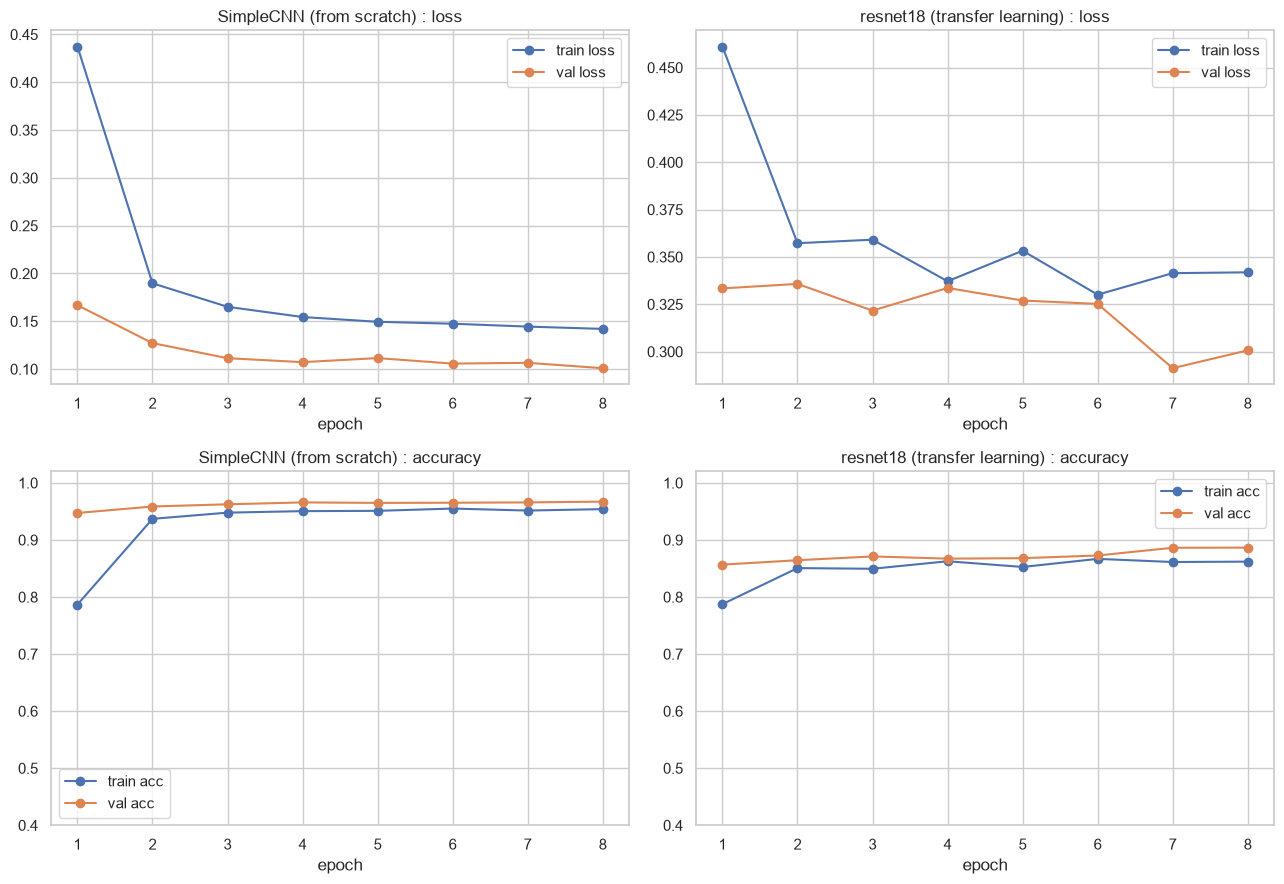

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, hist, title in zip(axes[0], [history_cnn, history_resnet], ["SimpleCNN (from scratch)", "resnet18 (transfer learning)"]):
    epochs_range = range(1, EPOCHS + 1)
    ax.plot(epochs_range, hist["train_loss"], marker="o", label="train loss")
    ax.plot(epochs_range, hist["val_loss"], marker="o", label="val loss")
    ax.set_title(f"{title} : loss")
    ax.set_xlabel("epoch")
    ax.legend()

for ax, hist, title in zip(axes[1], [history_cnn, history_resnet], ["SimpleCNN (from scratch)", "resnet18 (transfer learning)"]):
    epochs_range = range(1, EPOCHS + 1)
    ax.plot(epochs_range, hist["train_acc"], marker="o", label="train acc")
    ax.plot(epochs_range, hist["val_acc"], marker="o", label="val acc")
    ax.set_title(f"{title} : accuracy")
    ax.set_xlabel("epoch")
    ax.set_ylim(0.4, 1.02)
    ax.legend()

plt.tight_layout()
plt.show()

In [10]:
comparison = pd.DataFrame({
    "model": ["SimpleCNN (from scratch)", "resnet18 (transfer learning)"],
    "trainable_params": [
        sum(p.numel() for p in simple_cnn.parameters() if p.requires_grad),
        sum(p.numel() for p in resnet_transfer.parameters() if p.requires_grad),
    ],
    "final_val_loss": [history_cnn["val_loss"][-1], history_resnet["val_loss"][-1]],
    "final_val_accuracy": [history_cnn["val_acc"][-1], history_resnet["val_acc"][-1]],
    "final_val_f1_parasitized": [history_cnn["val_f1"][-1], history_resnet["val_f1"][-1]],
    "best_val_accuracy": [max(history_cnn["val_acc"]), max(history_resnet["val_acc"])],
    "training_time_sec": [round(time_cnn, 1), round(time_resnet, 1)],
})
display(comparison)

,model,trainable_params,final_val_loss,final_val_accuracy,final_val_f1_parasitized,best_val_accuracy,training_time_sec
0,SimpleCNN (from scratch),548258,0.100954,0.967154,0.961773,0.967154,119.9
1,resnet18 (transfer learning),1026,0.300686,0.886558,0.872558,0.886558,165.0


### Lecture de la comparaison

La cellule ci-dessus affiche des chiffres réels, tout juste calculés, l'interprétation découle directement de ce tableau plutôt que d'une hypothèse posée à l'avance sur l'approche qui l'emporterait sur ce dataset.

## 8. Sauvegarde du meilleur modèle

In [11]:
best_idx = comparison["best_val_accuracy"].idxmax()
best_model_name = comparison.loc[best_idx, "model"]

if "resnet18" in best_model_name:
    best_model = resnet_transfer
    architecture = "resnet18_transfer"
else:
    best_model = simple_cnn
    architecture = "simple_cnn"

checkpoint = {
    "architecture": architecture,
    "state_dict": best_model.state_dict(),
    "img_size": IMG_SIZE,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
    "label_to_idx": LABEL_TO_IDX,
    "val_accuracy": comparison.loc[best_idx, "final_val_accuracy"],
    "val_f1_parasitized": comparison.loc[best_idx, "final_val_f1_parasitized"],
}
torch.save(checkpoint, MODELS_DIR / "best_model.pt")

display(
    Markdown(
        f"**Meilleur modèle retenu :** `{best_model_name}`  \n"
        f"Sauvegardé dans `models/best_model.pt` avec une accuracy de validation finale de `{checkpoint['val_accuracy']:.4f}` "
        f"et un F1 de validation (Parasitized) de `{checkpoint['val_f1_parasitized']:.4f}`."
    )
)

**Meilleur modèle retenu :** `SimpleCNN (from scratch)`  
Sauvegardé dans `models/best_model.pt` avec une accuracy de validation finale de `0.9672` et un F1 de validation (Parasitized) de `0.9618`.

## Résumé et passage de relais au Notebook 04

* Les deux modèles ont été entraînés sur le même nombre d'epochs, sur le même sous-échantillon stratifié du jeu d'entraînement (3 000 images par classe, 6 000 au total), évalués sur le split de validation complet.
* Le tableau de comparaison et les courbes ci-dessus sont lus directement à partir de cette exécution, pas supposés. Voir la Section 7 pour l'accuracy, le F1 et le temps d'entraînement réels de chaque modèle.
* Le meilleur modèle selon l'accuracy de validation est sauvegardé dans `models/best_model.pt` (ignoré par git) avec assez de métadonnées (nom de l'architecture, taille d'image, statistiques de normalisation, mapping des labels) pour que le Notebook 04 puisse le recharger sans avoir à relire ce notebook.
* Le Notebook 04 évalue ce modèle sauvegardé sur le jeu de test mis de côté, qu'aucun des deux modèles n'a vu pendant l'entraînement ou la sélection de modèle ici.